# It Didn't Train. Now What?

You have seen hybrid models work. This notebook is about the other case — the
one you will actually meet on Monday, where you wire a network into your own
model, hit `.backward()`, and the loss sits there like a stone.

Almost every time this happens it is one of six things, and all six are
diagnosable in a couple of minutes if you know what to look for. We'll
reproduce each failure on a real model with real data, watch it fail, and
then fix it.

:::{admonition} Time check — 12 minutes
:class: tip
What you will be able to do afterwards:
- read a gradient-norm curve and tell vanishing memory from an unstable solver
- find the operation in your model that is silently zeroing a gradient, and
  replace it without destroying the physics
- recognize a scaling failure from the shape of the loss curve alone
- say something honest about what hybrid models do and do not do to
  equifinality
- work through a 60-second checklist before asking anyone for help
:::

## Motivation

The uncomfortable thing about gradient-based training is that it fails
*quietly*. A derivative-free calibration that goes wrong usually looks wrong:
the objective bounces around, parameters pile up on their bounds, you notice.
Automatic differentiation is more polite. It hands you a number. The number may
be zero, or the exact gradient of a computation that has nothing to do with the
hydrology you intended, and nothing in the output says so.

So the skill this notebook is teaching is not "how to train a neural network."
It is **how to interrogate a gradient** — which is a hydrologist's skill, not a
machine learning one. You already know how to ask whether a flux is
physically plausible. This is the same habit applied to a derivative.

## What we'll cover

1. The model we're going to break
2. Long unrolls: vanishing memory, and what to do about it
3. The operation that kills your gradient
4. Scaling and initialization
5. Stiffness, and the explicit solver that fails without telling you
6. Equifinality: does hybrid modeling help?
7. A checklist worth keeping

In [1]:
# --- Colab bootstrap: installs the workshop package on first run -----------
try:
    import workshop_utils
except ImportError:
    %pip install -q "git+https://github.com/BennettHydroLab/differentiable_modeling_workshop.git"
    import workshop_utils

In [2]:
import time

import numpy as np
import torch
import matplotlib.pyplot as plt

from workshop_utils import (
    nse, set_style, COLORS,
    MLP, ParamMap, smooth_threshold, smooth_min, smooth_relu, soft_clamp,
)
from workshop_utils.data import (
    load_basin, split_by_water_year, standardizer, attributes,
    BASIN_TEMPERATE, BASIN_SNOWY, BASIN_LABELS,
)

set_style()
torch.manual_seed(0)

## 1. The model we're going to break

This is the same HBV-lite you calibrated in `00_setup_and_motivation`: a soil
store feeding a fast and a slow reservoir, six parameters, batched over a
leading parameter dimension so the only Python loop is over time.

Two things have been added, and both exist purely so we can run the
experiments below:

- `u0` accepts **tensors**, so we can differentiate the simulation with respect
  to its own initial state. That is how you measure how far back in time a
  gradient actually reaches.
- a `smooth` switch replaces every hard `clamp` and `minimum` with the
  `smooth_*` surrogates from `workshop_utils.nn`. Section 3 is about why you
  would want that.

Notice, before we go further, how many non-differentiable operations are in
this ordinary conceptual model: three `torch.clamp` calls and one
`torch.minimum`, in twenty lines. That is not unusual. That is what a bucket
model *is*.

In [3]:
PARAM_NAMES = ["FC", "beta", "LP", "K_fast", "K_slow", "PERC"]
LO = torch.tensor([ 50., 1.0, 0.3, 0.05, 0.005, 0.1])
HI = torch.tensor([500., 5.0, 1.0, 0.60, 0.150, 3.0])
pmap = ParamMap(LO, HI)


def simulate(P, E, theta, u0=(50., 5., 20.), smooth=False,
             return_state=False, return_internals=False):
    """HBV-lite: notebook 00's model, with a tensor-tolerant u0 and a smooth switch.

    P, E   : (time,) precipitation and PET, mm/day
    theta  : (n, 6) parameter sets       ->  returns (n, time) discharge
    """
    FC, beta, LP, K_fast, K_slow, PERC = theta.T
    n = theta.shape[0]
    mk = lambda v: v.expand(n).clone() if torch.is_tensor(v) else torch.full((n,), float(v))
    S_soil, S_fast, S_slow = mk(u0[0]), mk(u0[1]), mk(u0[2])

    if smooth:
        # beta here is the softness of the surrogate, in the units of its
        # arguments -- not HBV's beta. See workshop_utils.nn docstrings.
        clamp01 = lambda z: soft_clamp(z, 0.0, 1.0, beta=20.0)
        pos     = lambda z: smooth_relu(z, beta=2.0)
        mn      = lambda a, b: smooth_min(a, b, beta=2.0)
    else:
        clamp01 = lambda z: torch.clamp(z, 0., 1.)
        pos     = lambda z: torch.clamp(z, min=0.)
        mn      = torch.minimum

    discharge, ets, q_slows = [], [], []
    for t in range(P.shape[0]):
        wetness = clamp01(S_soil / FC)
        recharge = P[t] * wetness ** beta
        et = E[t] * clamp01(S_soil / (LP * FC))
        S_soil = pos(S_soil + P[t] - recharge - et)

        perc = mn(PERC, S_fast)
        S_fast = S_fast + recharge - perc
        q_fast = K_fast * S_fast
        S_fast = S_fast - q_fast

        S_slow = S_slow + perc
        q_slow = K_slow * S_slow
        S_slow = S_slow - q_slow

        discharge.append(q_fast + q_slow)
        if return_internals:
            ets.append(et)
            q_slows.append(q_slow)

    q = torch.stack(discharge, dim=1)
    if return_internals:
        return q, torch.stack(ets, 1), torch.stack(q_slows, 1)
    if return_state:
        return q, (S_soil, S_fast, S_slow)
    return q

In [4]:
SPINUP = 365
ds = load_basin(BASIN_TEMPERATE)
split = split_by_water_year(ds, train=(1998, 2000), test=(2001, 2003), spinup_days=SPINUP)


def arrays(d):
    return (torch.tensor(d.prcp.values, dtype=torch.float32),
            torch.tensor(d.pet.values, dtype=torch.float32),
            torch.tensor(d.qobs.values, dtype=torch.float32))


P, E, Q = arrays(split["train"])
print(f"{BASIN_LABELS[BASIN_TEMPERATE]}")
print(f"training window: {len(P)} days ({SPINUP} of them spin-up)")

Cowpasture River, VA (humid temperate)
training window: 1461 days (365 of them spin-up)


## 2. Long unrolls: how far back does a gradient reach?

A 30-year daily simulation is a 10,957-step recurrence. Every timestep is a
function of the one before it, so the gradient of today's loss with respect to
something that happened in 1994 is a product of 5,000-odd Jacobians. Products
of many numbers do one of two things: they go to zero, or they go to infinity.
This is the vanishing/exploding gradient problem, and it is the *same* problem
recurrent networks have — you have simply arrived at it from the physics side.

Let's measure it rather than assert it. Make the initial soil store a variable,
run the model for `L` days, and ask how much the discharge on the last day
depends on it:

$$ \left| \frac{\partial q_L}{\partial S_{\text{soil}}(0)} \right| $$

This number is the model's **memory**, and it is also exactly the factor by
which a gradient arriving from day `L` is attenuated by the time it reaches
anything that happened on day 0.

12 runs in 2.2 s


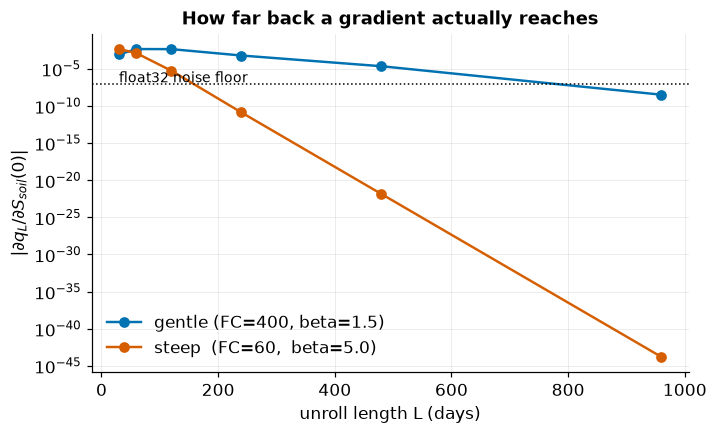

In [5]:
theta_gentle = torch.tensor([[400., 1.5, 0.8, 0.20, 0.02, 1.0]])   # big store, mild beta
theta_steep  = torch.tensor([[ 60., 5.0, 0.5, 0.55, 0.10, 2.5]])   # small store, steep beta


def memory(theta, L):
    """|d q_L / d S_soil(0)| -- how much the last day remembers the first."""
    S0 = torch.tensor(50.0, requires_grad=True)
    q = simulate(P[:L], E[:L], theta, u0=(S0, 5., 20.))[0]
    (g,) = torch.autograd.grad(q[-1], S0, allow_unused=True)
    return 0.0 if g is None else abs(g.item())


t0 = time.time()
Ls = [30, 60, 120, 240, 480, 960]
mem = {name: [memory(th, L) for L in Ls]
       for name, th in [("gentle (FC=400, beta=1.5)", theta_gentle),
                        ("steep  (FC=60,  beta=5.0)", theta_steep)]}
print(f"{len(Ls) * 2} runs in {time.time() - t0:.1f} s")

fig, ax = plt.subplots(figsize=(7, 4))
for (name, vals), c in zip(mem.items(), [COLORS["physics"], COLORS["ml"]]):
    ax.semilogy(Ls, np.maximum(vals, 1e-50), "o-", color=c, label=name)
ax.axhline(1e-7, color="k", ls=":", lw=1)
ax.text(Ls[0], 1.5e-7, "float32 noise floor", fontsize=9)
ax.set_xlabel("unroll length L (days)")
ax.set_ylabel(r"$|\partial q_L / \partial S_{soil}(0)|$")
ax.set_title("How far back a gradient actually reaches")
ax.legend()
plt.show()

Both curves fall off a cliff, and the steep parameter set falls faster:
by 240 days its gradient is around $10^{-11}$, and by 960 days it is
$10^{-44}$ — which in `float32` is indistinguishable from zero.

That is worth sitting with for a second. **A conceptual hydrologic model is a
contraction.** Every store leaks, so information about its initial content is
destroyed a little each day, on purpose — that is why spin-up works at all.
The consequence for training is that a loss computed on day 960 carries *no
usable information* about anything that happened on day 1. Unrolling 30 years
to compute one gradient is not just expensive, it is largely pointless: the
long end of the graph contributes nothing.

:::{admonition} Why this matters for hydrology
:class: note
The rate of decay is set by your parameters, so **the length of unroll you need
is a hydrologic question, not a numerical one**. A basin with a 200-day
baseflow recession genuinely requires a longer window than a flashy one. Look
at your slow store's residence time and use that, rather than a round number
someone put in a config file.
:::

### The fix: truncated BPTT with the state carried forward

The standard answer is to cut the graph into windows. You simulate a window,
backpropagate within it, then **carry the physical state into the next window
with `.detach()`** so the hydrology continues but the graph does not.

This is exactly what {cite}`kalauni2025hybrid` do — 480 half-hourly steps
(about 10 days) with stride 460, seeding the next window's ODE state from the
previous one — and it is why their model has hydrologic memory without an
intractable graph.

In [6]:
def train(mode, n_steps=10, window=120, lr=0.25):
    """Calibrate the 6 parameters, either full-window or truncated."""
    torch.manual_seed(0)
    raw = torch.zeros(1, 6, requires_grad=True)
    opt = torch.optim.Adam([raw], lr=lr)
    scores, depth, t0 = [], 0, time.time()

    for step in range(n_steps):
        if mode == "full":
            opt.zero_grad()
            q = simulate(P, E, pmap(raw))[0]
            loss = ((q[SPINUP:] - Q[SPINUP:]) ** 2).mean()
            loss.backward()
            opt.step()
            depth = len(P)
        else:
            u = (torch.tensor(50.), torch.tensor(5.), torch.tensor(20.))
            for a in range(0, len(P), window):
                b = min(a + window, len(P))
                opt.zero_grad()
                q, u_end = simulate(P[a:b], E[a:b], pmap(raw), u0=u, return_state=True)
                if b > SPINUP:                       # don't score the spin-up
                    keep = slice(max(0, SPINUP - a), None)
                    loss = ((q[0][keep] - Q[a:b][keep]) ** 2).mean()
                    loss.backward()
                    opt.step()
                u = tuple(v.detach() for v in u_end)   # physics continues, graph does not
            depth = window

        with torch.no_grad():
            q = simulate(P, E, pmap(raw))[0]
            scores.append(float(nse(q[SPINUP:], Q[SPINUP:])))

    return scores, depth, time.time() - t0


s_full, d_full, t_full = train("full")
s_tb, d_tb, t_tb = train("tbptt")

print(f"{'':22}{'graph depth':>13}{'wall clock':>12}{'final NSE':>12}")
print("-" * 59)
print(f"{'full-window BPTT':22}{d_full:>11} steps{t_full:>10.1f} s{s_full[-1]:>12.3f}")
print(f"{'TBPTT (120-day)':22}{d_tb:>11} steps{t_tb:>10.1f} s{s_tb[-1]:>12.3f}")

                        graph depth  wall clock   final NSE
-----------------------------------------------------------
full-window BPTT             1461 steps      11.6 s       0.624
TBPTT (120-day)               120 steps       9.3 s       0.562


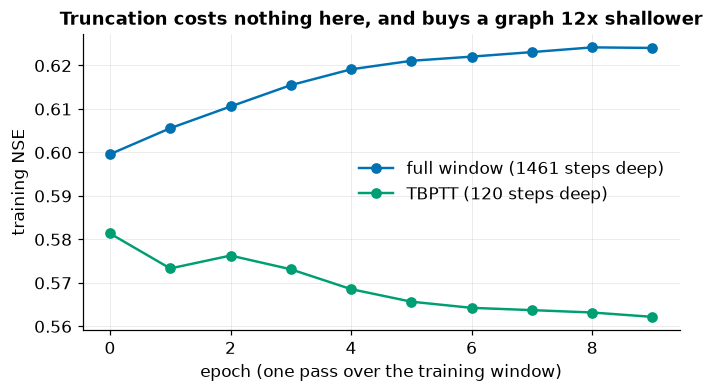

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(s_full, "o-", color=COLORS["physics"], label=f"full window ({d_full} steps deep)")
ax.plot(s_tb, "o-", color=COLORS["hybrid"], label=f"TBPTT ({d_tb} steps deep)")
ax.set_xlabel("epoch (one pass over the training window)")
ax.set_ylabel("training NSE")
ax.set_title("Truncation costs nothing here, and buys a graph 12x shallower")
ax.legend()
plt.show()

Same wall clock, same data, a graph an order of magnitude shallower — and
**more optimizer updates per pass**, because each window gives you one. At
1,096 days the full graph still fits in memory comfortably, so truncation is a
convenience. At 10,957 days, or at half-hourly resolution, it stops being
optional.

Three more mitigations, in the order you should reach for them:

| Symptom | Fix | Where it comes from |
|---|---|---|
| Loss plateaus, gradient norm tiny | shorter windows, carry state | {cite}`kalauni2025hybrid` |
| Occasional `NaN` or a huge loss spike | `torch.nn.utils.clip_grad_norm_(params, 1.0)` | standard; used in {cite}`lamichhane2025dynamic` |
| Early epochs dominated by bad initial state | exclude spin-up from the loss | both papers |

Gradient clipping deserves a word, because people apply it superstitiously.
It does not fix a vanishing gradient — it only bounds an exploding one. And
in a hydrologic model, **an exploding gradient is nearly always a symptom, not
a disease**: dissipative systems contract, so if your gradients are growing,
your time step is probably too long for your fastest store. We'll come back to
that in section 5.

## 3. The operation that kills your gradient

`theory/01_gradients_and_autodiff` showed you that `torch.minimum` hands back a
zero derivative on the branch it did not take. Here is what that does to an
actual training run.

The setup is a synthetic-truth twin experiment, because minicamels has no
observed SWE — there is nothing to validate a snow simulation against, so we
manufacture a truth we know. We add a degree-day snow module to the front of
HBV-lite, run it with a known rain/snow threshold $T_{\text{snow}} = 1.0$ °C on
the snow-dominated basin, and treat the resulting discharge as observations.
Then we try to recover $T_{\text{snow}}$, starting from a deliberately wrong
$-2.5$ °C, while also fitting the six bucket parameters.

Two versions of the same module. The only difference is one line.

In [8]:
MELT_FACTOR = 3.0   # mm/degC/day, held fixed -- we are only chasing T_snow here


def snow_module(P, temp, t_snow, hard=True, sharpness=2.0):
    """Degree-day snow. Returns rain + melt, the water HBV-lite actually sees."""
    if hard:
        f_snow = torch.where(temp < t_snow, 1.0, 0.0)          # <-- the culprit
    else:
        f_snow = smooth_threshold(-temp, center=-t_snow, sharpness=sharpness)

    swe, out = torch.zeros(()), []
    for t in range(len(P)):
        snowfall = P[t] * f_snow[t]
        swe = swe + snowfall
        melt = torch.clamp(MELT_FACTOR * temp[t], min=0.)
        melt = torch.minimum(melt, swe) if hard else smooth_min(melt, swe, beta=5.0)
        swe = swe - melt
        out.append(P[t] - snowfall + melt)
    return torch.stack(out)


snowy = split_by_water_year(load_basin(BASIN_SNOWY), train=(1999, 1999),
                            test=(2000, 2000), spinup_days=SPINUP)
P_s, E_s, _ = arrays(snowy["train"])
temp_s = torch.tensor(snowy["train"].tmean.values, dtype=torch.float32)

THETA_TRUE = torch.tensor([[250., 2.5, 0.7, 0.30, 0.03, 1.5]])
T_SNOW_TRUE = 1.0

with torch.no_grad():
    q_true = simulate(snow_module(P_s, temp_s, torch.tensor(T_SNOW_TRUE)), E_s, THETA_TRUE)[0]

print(f"{BASIN_LABELS[BASIN_SNOWY]}")
print(f"synthetic truth: T_snow = {T_SNOW_TRUE} degC, mean flow {q_true.mean():.2f} mm/day")

Johnson Creek, ID (snow dominated)
synthetic truth: T_snow = 1.0 degC, mean flow 2.40 mm/day


In [9]:
def recover_t_snow(hard, n_steps=20, sharpness=2.0, start=-2.5):
    torch.manual_seed(0)
    t_snow = torch.tensor(start, requires_grad=True)
    raw = pmap.inverse(THETA_TRUE).clone().requires_grad_(True)
    opt = torch.optim.Adam([{"params": [t_snow], "lr": 0.2},
                            {"params": [raw],    "lr": 0.05}])

    traj, losses, g0 = [], [], None
    for step in range(n_steps):
        opt.zero_grad()
        water = snow_module(P_s, temp_s, t_snow, hard=hard, sharpness=sharpness)
        q = simulate(water, E_s, pmap(raw))[0]
        loss = ((q[SPINUP:] - q_true[SPINUP:]) ** 2).mean()
        loss.backward()
        if step == 0:
            g0 = t_snow.grad
        opt.step()
        traj.append(t_snow.item())
        losses.append(loss.item())
    return traj, losses, g0


traj_h, loss_h, g_h = recover_t_snow(hard=True)
traj_s, loss_s, g_s = recover_t_snow(hard=False)

print(f"hard threshold   : dL/dT_snow at step 0 = {g_h}")
print(f"smooth threshold : dL/dT_snow at step 0 = {g_s.item():.3f}")
print()
print(f"{'':18}{'T_snow start':>14}{'T_snow final':>14}{'loss final':>12}")
print("-" * 58)
print(f"{'hard':18}{traj_h[0]:>14.2f}{traj_h[-1]:>14.2f}{loss_h[-1]:>12.4f}")
print(f"{'smooth (k=2)':18}{traj_s[0]:>14.2f}{traj_s[-1]:>14.2f}{loss_s[-1]:>12.4f}")
print(f"{'truth':18}{'':>14}{T_SNOW_TRUE:>14.2f}{0.0:>12.4f}")

hard threshold   : dL/dT_snow at step 0 = None
smooth threshold : dL/dT_snow at step 0 = -9.066

                    T_snow start  T_snow final  loss final
----------------------------------------------------------
hard                       -2.50         -2.50      8.4143
smooth (k=2)               -2.30          0.49      0.5106
truth                                     1.00      0.0000


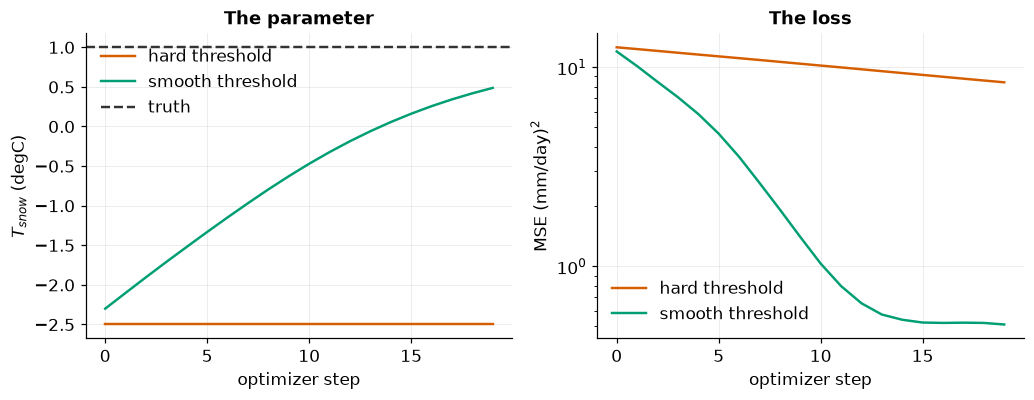

In [10]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.6))
a1.plot(traj_h, color=COLORS["ml"], label="hard threshold")
a1.plot(traj_s, color=COLORS["hybrid"], label="smooth threshold")
a1.axhline(T_SNOW_TRUE, color=COLORS["obs"], ls="--", label="truth")
a1.set_xlabel("optimizer step"); a1.set_ylabel(r"$T_{snow}$ (degC)")
a1.set_title("The parameter"); a1.legend()

a2.semilogy(loss_h, color=COLORS["ml"], label="hard threshold")
a2.semilogy(loss_s, color=COLORS["hybrid"], label="smooth threshold")
a2.set_xlabel("optimizer step"); a2.set_ylabel("MSE (mm/day)$^2$")
a2.set_title("The loss"); a2.legend()
plt.show()

`dL/dT_snow` came back as **`None`**. Not small — absent. `temp < t_snow` is a
boolean comparison, and a boolean has no derivative, so `t_snow` was never
connected to the loss at all. The optimizer dutifully did nothing to it for
twenty steps while the six bucket parameters contorted themselves trying to
compensate, and the loss stalled at roughly sixteen times the smooth model's.

:::{admonition} Gotcha
:class: warning
`None` is the *lucky* version. In a model with other trainable parameters,
`loss.backward()` succeeds, the run looks normal, and one parameter is silently
frozen while the rest absorb its job. You get a plausible hydrograph fitted by
the wrong mechanism. Always print `p.grad` for every parameter after your first
backward pass. A `None` or an exact `0.0` is a bug report.

Two PyTorch-specific traps in the same family, from {cite}`shen2023differentiable`:
`torch.where` **is** differentiable in its branches but will propagate a `NaN`
gradient from the branch you did *not* take if that branch computes one — so
mask the *input*, not the output. And writing in place into a tensor that needs
grad (`u[t] = ...`) will either raise a version-counter error or quietly break
the graph; accumulate into a Python list and `torch.stack` it, as `simulate`
does above.
:::

### How sharp should the surrogate be?

This is the question the `smooth_*` docstrings hedge on, and rightly — it is a
genuine trade-off, so let's look at it. Sweep the loss surface in
$T_{\text{snow}}$ at several sharpness values. Forward-only, so it is cheap.

100 forward runs in 12.1 s


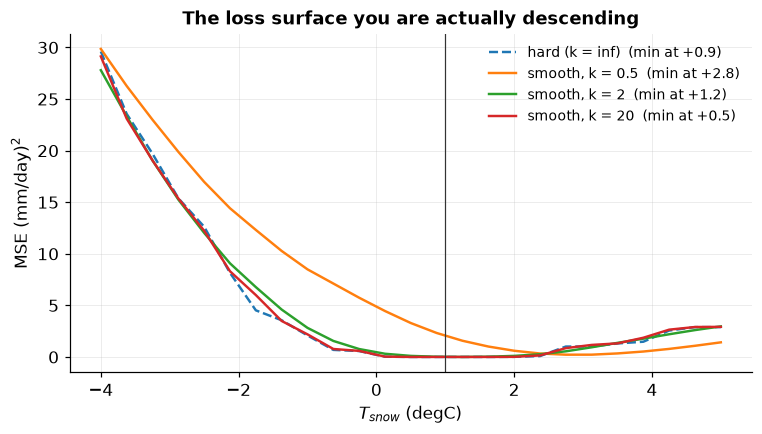

In [11]:
def loss_at(t_val, hard, k=2.0):
    with torch.no_grad():
        water = snow_module(P_s, temp_s, torch.tensor(float(t_val)), hard=hard, sharpness=k)
        q = simulate(water, E_s, THETA_TRUE)[0]
        return float(((q[SPINUP:] - q_true[SPINUP:]) ** 2).mean())


t0 = time.time()
grid = np.linspace(-4, 5, 25)
curves = {"hard (k = inf)": np.array([loss_at(v, True) for v in grid])}
for k in [0.5, 2.0, 20.0]:
    curves[f"smooth, k = {k:g}"] = np.array([loss_at(v, False, k) for v in grid])
print(f"{len(grid) * len(curves)} forward runs in {time.time() - t0:.1f} s")

fig, ax = plt.subplots(figsize=(8, 4))
for (name, c), col in zip(curves.items(),
                          [COLORS["obs"], COLORS["extra"], COLORS["hybrid"], COLORS["ml"]]):
    ax.plot(grid, c, label=f"{name}  (min at {grid[c.argmin()]:+.1f})",
            ls="--" if name.startswith("hard") else "-")
ax.axvline(T_SNOW_TRUE, color=COLORS["obs"], lw=0.8)
ax.set_xlabel(r"$T_{snow}$ (degC)"); ax.set_ylabel("MSE (mm/day)$^2$")
ax.set_title("The loss surface you are actually descending")
ax.legend(fontsize=9)
plt.show()

In [12]:
# And what a distant optimizer can feel: the gradient 3.5 degC from the optimum.
print(f"{'sharpness k':>12}{'|dL/dT_snow| at T_snow = -2.5':>32}")
print("-" * 44)
for k in [0.5, 1.0, 2.0, 5.0, 20.0, 100.0]:
    ts = torch.tensor(-2.5, requires_grad=True)
    q = simulate(snow_module(P_s, temp_s, ts, hard=False, sharpness=k), E_s, THETA_TRUE)[0]
    (g,) = torch.autograd.grad(((q[SPINUP:] - q_true[SPINUP:]) ** 2).mean(), ts)
    print(f"{k:>12g}{abs(g.item()):>32.3f}")

 sharpness k   |dL/dT_snow| at T_snow = -2.5
--------------------------------------------


         0.5                           7.691


           1                           8.042


           2                           9.066


           5                           9.904


          20                          16.020


         100                           7.699


Read those two outputs together and the trade-off is explicit:

- **Too soft** (`k = 0.5`): the surface is beautifully smooth and its minimum is
  in the wrong place — about 2 °C off. You will converge, confidently, to a
  biased answer. The surrogate is no longer the model you meant to write.
- **About right** (`k = 2` to `5`): minimum within a few tenths of a degree of
  truth, and a gradient you can feel from 3.5 °C away.
- **Too sharp** (`k = 20`, `k = 100`): the approximation error keeps shrinking,
  but the surface is turning back into the staircase we started with. The
  gradient is concentrated in a band a few tenths of a degree wide, and an
  optimizer that starts outside it gets almost nothing.

So `sharpness` is not a nuisance parameter to set as large as you dare. **It is
the width of the transition you believe in.** A rain-snow threshold really is
smeared over a degree or two of air temperature — sub-grid variability,
wet-bulb effects, mixed-phase precipitation — so `k` of 1 to 2 is a
*physical* statement, not a numerical convenience.

Which is the nice part of this story: hydrologists have been doing this for
decades without calling it anything. SNOW-17's dual `PXTEMP1`/`PXTEMP2`
partitioning is already a linear ramp. {cite}`knoben2019marrmot` rewrote 46
conceptual models as smooth continuous state-space systems, and is the best
cookbook available for this exact job. {cite}`kavetski2010ancient` and
{cite}`clark2010ancient` made the argument years before anyone said
"differentiable": thresholds and hard switches corrupt the objective surface,
and a gradient of a corrupted surface is worse than useless because it looks
fine.

## 4. Scaling and initialization

Here is the whole problem in one line of output. Look at the raw forcings.

In [13]:
FORCINGS = ["prcp", "tmean", "srad", "vp"]
X = torch.stack([torch.tensor(split["train"][v].values, dtype=torch.float32)
                 for v in FORCINGS], dim=1)

print(f"{'variable':>8}{'mean':>10}{'std':>10}   units")
print("-" * 44)
for i, (v, unit) in enumerate(zip(FORCINGS, ["mm/day", "degC", "W/m2", "Pa"])):
    print(f"{v:>8}{X[:, i].mean():>10.2f}{X[:, i].std():>10.2f}   {unit}")

variable      mean       std   units
--------------------------------------------
    prcp      3.06      6.37   mm/day
   tmean     10.89      8.58   degC
    srad    336.48    113.26   W/m2
      vp    967.51    518.30   Pa


Vapour pressure is in the hundreds of Pascals, radiation in the hundreds of
W/m², precipitation in single-digit mm/day. A `tanh` unit saturates outside
roughly $\pm 2$. Feed that table into a freshly initialized network and every
hidden unit is pinned at $\pm 1$, where its derivative is zero — so the
gradient dies on the *first layer*, before it ever reaches the physics.

`workshop_utils.data.standardizer` fits mean and standard deviation and returns
a pair of closures. Fit it on the **training period only**; reusing test-period
statistics leaks information across your split, which is the same sin as
shuffling days.

Let's train a dynamic-parameter hybrid — form (1), $\theta_t = \hat{g}(\mathrm{NN}_\varphi(x_t))$,
the same structure as the applications notebooks' dynamic parameterization —
twice, with and without that one call.

In [14]:
normalize, _ = standardizer(X)       # fitted on the TRAINING window only
X_std = normalize(X)

THETA_BASE = torch.tensor([[250., 2.5, 0.7, 0.30, 0.03, 1.5]])
raw_base = pmap.inverse(THETA_BASE)


class DynamicParams(torch.nn.Module):
    """theta_t = ParamMap(raw_base + NN_phi(x_t)).

    The last layer is zero-initialized, so at step 0 the network outputs zero,
    theta_t equals THETA_BASE exactly, and the hybrid *is* the physics model.
    That is the general rule from research_brief.md 6.4: start from the
    calibrated physics and let training improve on it, never from noise.
    """

    def __init__(self, n_in):
        super().__init__()
        self.net = MLP(n_in, 6, hidden=16, depth=2)
        torch.nn.init.zeros_(self.net.net[-1].weight)
        torch.nn.init.zeros_(self.net.net[-1].bias)

    def forward(self, x):
        return raw_base + self.net(x)


def simulate_dynamic(P, E, theta_t, u0=(50., 5., 20.)):
    """HBV-lite with a fresh parameter vector every day. theta_t: (time, 6)."""
    S_soil, S_fast, S_slow = [torch.tensor(float(v)) for v in u0]
    out = []
    for t in range(P.shape[0]):
        FC, beta, LP, K_fast, K_slow, PERC = theta_t[t]
        wetness = torch.clamp(S_soil / FC, 0., 1.)
        recharge = P[t] * wetness ** beta
        et = E[t] * torch.clamp(S_soil / (LP * FC), 0., 1.)
        S_soil = torch.clamp(S_soil + P[t] - recharge - et, min=0.)
        perc = torch.minimum(PERC, S_fast)
        S_fast = S_fast + recharge - perc
        q_fast = K_fast * S_fast
        S_fast = S_fast - q_fast
        S_slow = S_slow + perc
        q_slow = K_slow * S_slow
        S_slow = S_slow - q_slow
        out.append(q_fast + q_slow)
    return torch.stack(out)


def train_hybrid(X_in, n_steps=15, lr=0.02):
    torch.manual_seed(0)
    model = DynamicParams(X_in.shape[1])
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    losses, pre = [], None
    for step in range(n_steps):
        opt.zero_grad()
        if step == 0:   # first-layer pre-activations, before anything is learned
            pre = (X_in @ model.net.net[0].weight.T + model.net.net[0].bias).detach()
        q = simulate_dynamic(P, E, pmap(model(X_in)))
        loss = ((q[SPINUP:] - Q[SPINUP:]) ** 2).mean()
        loss.backward()
        opt.step()
        losses.append(loss.item())
    return losses, pre

In [15]:
t0 = time.time()
loss_raw, pre_raw = train_hybrid(X)
loss_std, pre_std = train_hybrid(X_std)
print(f"both runs in {time.time() - t0:.0f} s")

saturated = lambda pre: float(((1 - torch.tanh(pre) ** 2) < 0.01).float().mean())
print()
print(f"{'':16}{'mean |pre-act|':>16}{'tanh units dead':>18}{'loss: first':>13}{'last':>9}")
print("-" * 73)
print(f"{'raw units':16}{pre_raw.abs().mean():>16.1f}{saturated(pre_raw):>17.1%}"
      f"{loss_raw[0]:>13.3f}{loss_raw[-1]:>9.3f}")
print(f"{'standardized':16}{pre_std.abs().mean():>16.1f}{saturated(pre_std):>17.1%}"
      f"{loss_std[0]:>13.3f}{loss_std[-1]:>9.3f}")

both runs in 35 s

                  mean |pre-act|   tanh units dead  loss: first     last
-------------------------------------------------------------------------
raw units                  329.9            99.7%        1.263    1.085
standardized                 0.5             0.0%        1.263    0.576


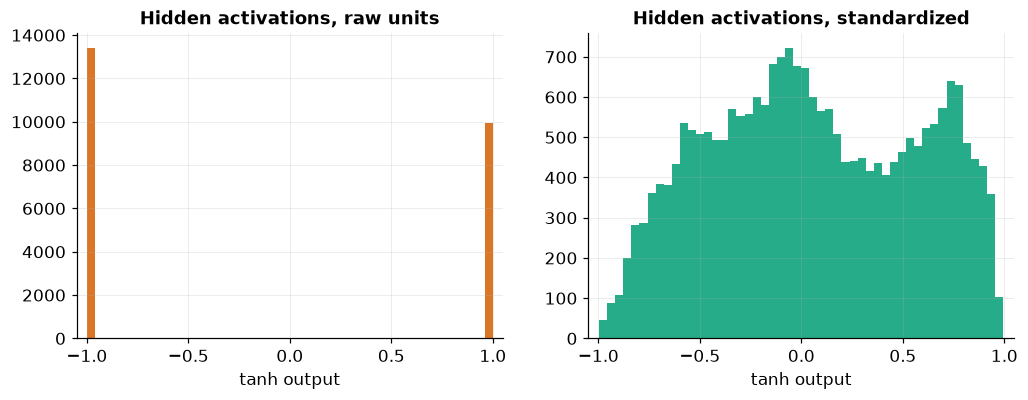

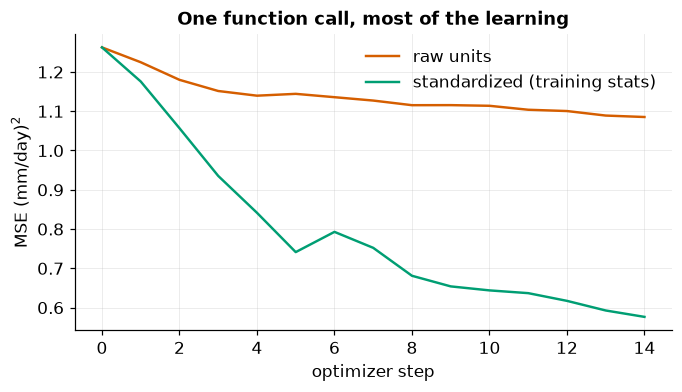

In [16]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.6))
a1.hist(np.tanh(pre_raw.numpy().ravel()), bins=50, color=COLORS["ml"], alpha=0.85)
a1.set_title("Hidden activations, raw units"); a1.set_xlabel("tanh output"); a1.set_xlim(-1.05, 1.05)
a2.hist(np.tanh(pre_std.numpy().ravel()), bins=50, color=COLORS["hybrid"], alpha=0.85)
a2.set_title("Hidden activations, standardized"); a2.set_xlabel("tanh output"); a2.set_xlim(-1.05, 1.05)
plt.show()

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(loss_raw, color=COLORS["ml"], label="raw units")
ax.plot(loss_std, color=COLORS["hybrid"], label="standardized (training stats)")
ax.set_xlabel("optimizer step"); ax.set_ylabel("MSE (mm/day)$^2$")
ax.set_title("One function call, most of the learning")
ax.legend()
plt.show()

Mean pre-activation of **330** with raw inputs, against 0.5 standardized.
Ninety-nine-point-seven percent of the hidden units start with a derivative
below 0.01 — pinned against the rails of the `tanh`. The loss curve is the
tell: it moves, slowly, because the *output* bias can still learn a constant
offset, but the network is not using its inputs at all. If you have ever
watched a loss curve sag gently and plateau well above where it should, this
is the first thing to check.

Three initialization rules, all used by the papers behind this workshop:

1. **Squash network outputs onto published physical ranges.** `ParamMap` is
   the sigmoid rescale {cite}`lamichhane2025dynamic` use to keep an LSTM's
   output inside SNOW-17's Table 1 bounds. An untrained network emits nonsense;
   this makes nonsense harmless.
2. **Start from the calibrated physics.** Zero-initializing the last layer, as
   `DynamicParams` does, means the hybrid at step 0 *is* the physics model with
   `THETA_BASE`. You can only improve from there. `ParamMap.inverse()` exists
   exactly for this warm start.
3. **Pre-train the network offline** against the formula it is replacing, if
   the closure has a wide dynamic range. {cite}`kalauni2025hybrid` do 5,000
   steps of log-space MSE against the physics' own aerodynamic resistance
   before going online — because $r_a$ spans 1 to 2,000 s/m and a randomly
   initialized network will not land anywhere near it.

## 5. Stiffness, and the solver that fails quietly

A system is **stiff** when it contains processes on wildly different
timescales. Hydrologic models are full of them: overland flow responds in
hours, a deep groundwater store in years. {cite}`kalauni2025hybrid` needed an
implicit ESDIRK solver in double precision for a soil heat column, and paid for
it in wall clock.

The failure mode you need to recognize does not look like a failure. Take the
simplest possible fast store, $dS/dt = -S/\tau$, integrate it with forward
Euler at $\Delta t = 1$ day, and compare against the analytic solution — which
is the habit worth keeping from the rest of this workshop: **check the tool
against a known answer before you use it in anger.**

We'll look at both the value and its derivative, because they fail at
different points.

In [17]:
S0 = 100.0


def outflow_euler(tau, dt, n_days=2.0):
    """Total outflow over n_days, by forward Euler. Differentiable in tau."""
    S = torch.tensor(S0)
    for _ in range(int(round(n_days / dt))):
        S = S + dt * (-S / tau)
    return S0 - S


def outflow_exact(tau, n_days=2.0):
    return S0 * (1 - torch.exp(-n_days / tau))


print(f"{'tau (d)':>9}{'dt/tau':>8}{'Euler y':>10}{'exact y':>10}"
      f"{'AD dy/dtau':>13}{'true dy/dtau':>14}")
print("-" * 66)
for tau_v, dt in [(5.0, 1.0), (2.0, 1.0), (1.0, 1.0), (0.7, 1.0), (0.4, 1.0), (0.7, 0.1)]:
    tau = torch.tensor(tau_v, requires_grad=True)
    y = outflow_euler(tau, dt)
    (g_ad,) = torch.autograd.grad(y, tau)

    tau2 = torch.tensor(tau_v, requires_grad=True)
    (g_ex,) = torch.autograd.grad(outflow_exact(tau2), tau2)

    flag = "  <-- WRONG SIGN" if g_ad * g_ex < 0 else ""
    note = "  (substepped)" if dt < 1 else ""
    print(f"{tau_v:>9.1f}{dt / tau_v:>8.2f}{y.item():>10.1f}{outflow_exact(tau2).item():>10.1f}"
          f"{g_ad.item():>13.2f}{g_ex.item():>14.2f}{flag}{note}")

  tau (d)  dt/tau   Euler y   exact y   AD dy/dtau  true dy/dtau
------------------------------------------------------------------
      5.0    0.20      36.0      33.0        -6.40         -5.36
      2.0    0.50      75.0      63.2       -25.00        -18.39
      1.0    1.00     100.0      86.5         0.00        -27.07
      0.7    1.43      81.6      94.3       174.93        -23.44  <-- WRONG SIGN
      0.4    2.50    -125.0      99.3      1875.00         -8.42  <-- WRONG SIGN
      0.7    0.14      95.4      94.3       -21.82        -23.44  (substepped)


Read the $\tau = 0.7$ row. The simulated outflow is 82 mm against a true 94 mm
— wrong, but not *obviously* wrong; drop that into a hydrograph and nothing
screams. The gradient, though, is $+175$ where the truth is $-23$. **It points
the wrong way.** An optimizer handed that number will walk uphill with complete
confidence, and your only symptom will be a calibration that converges to
something odd.

The $\tau = 1.0$ row is worse in its way: the AD gradient is exactly `0.00`.
At $\Delta t = \tau$ forward Euler empties the store completely in one step
regardless of $\tau$, so the derivative genuinely is zero — of the computation
you performed, which is not the computation you meant. Automatic
differentiation is doing its job perfectly. The job was mis-specified.

The last row is the fix, and it is dull: the same $\tau = 0.7$ with ten
substeps per day recovers $-21.8$ against a true $-23.4$.

:::{admonition} Gotcha
:class: warning
The rule of thumb: an explicit step is trustworthy while
$\Delta t / \tau \lesssim 0.2$ for your **fastest** store. If your daily model
has a routing reservoir with `K_fast = 0.6`, you are at $\Delta t/\tau = 0.6$
and your gradients are already distorted even though the simulation looks fine.

Three fixes, cheapest first. **Substep** the fast store. Use the **analytic
linear-reservoir solution** $S_{n+1} = S_n e^{-\Delta t/\tau}$, which is exact,
unconditionally stable, and perfectly differentiable — most conceptual routing
stores are linear, so this is usually free. Or go implicit, which in PyTorch
means writing the Newton solve yourself and differentiating through it.

And note what this means for the adjoint: {cite}`rackauckas2021universal` are
blunt that reverse-solve adjoints are "almost certainly unstable" on stiff
systems, and report `torchdiffeq`'s adjoint diverging on most of their
benchmark suite. For a daily explicit hydrologic model, a Python `for` loop
with autograd taping it — discretize-then-optimize — is exact, simple, and
fits in memory. That is the default. See `theory/02_neural_odes_and_udes`.
:::

## 6. Equifinality: does hybrid modeling help?

`00_setup_and_motivation` raised this and deferred it here. You know the
problem better than anyone reading a machine learning paper does: many
different parameter sets reproduce the hydrograph equally well
{cite}`beven2006manifesto`, so "calibrated" does not mean "identified."

Let's see how bad it is in this model. Five hundred forward-only simulations
cost about a tenth of a second, so we can sample thousands and simply look at
the set of parameter vectors that score within 0.02 NSE of the best one.

In [18]:
t0 = time.time()
with torch.no_grad():
    theta_pool = pmap(torch.randn(3000, 6) * 1.5)
    q_pool, et_pool, qslow_pool = simulate(P, E, theta_pool, return_internals=True)
    resid = ((q_pool[:, SPINUP:] - Q[SPINUP:]) ** 2).sum(1)
    denom = ((Q[SPINUP:] - Q[SPINUP:].mean()) ** 2).sum()
    scores = 1 - resid / denom
    et_total = et_pool[:, SPINUP:].sum(1)
    baseflow_frac = qslow_pool[:, SPINUP:].sum(1) / q_pool[:, SPINUP:].sum(1)

best = scores.argmax()
behavioral = scores > scores[best] - 0.02
print(f"3000 simulations in {time.time() - t0:.2f} s")
print(f"best NSE {scores[best]:.3f}; {int(behavioral.sum())} sets within 0.02 of it")

3000 simulations in 0.36 s
best NSE 0.625; 50 sets within 0.02 of it


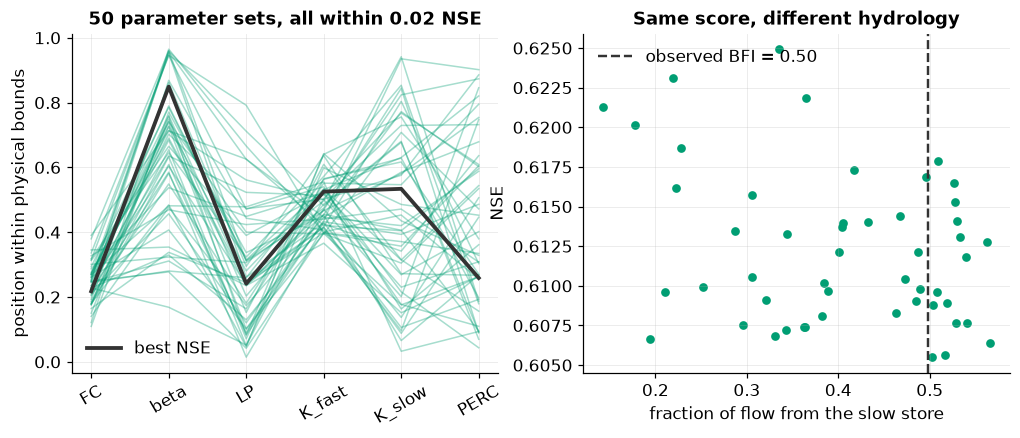

K_slow among behavioral sets : 0.010 to 0.141  (15x)
total ET                     : 2239 to 2424 mm
baseflow fraction            : 0.14 to 0.57

behavioral on NSE alone           : 50
  ... and consistent with observed BFI : 20


In [19]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))

# Parallel coordinates: every behavioral set, scaled onto its own bounds.
unit = (theta_pool[behavioral] - LO) / (HI - LO)
for row in unit:
    a1.plot(range(6), row.numpy(), color=COLORS["hybrid"], alpha=0.35, lw=1)
a1.plot(range(6), ((theta_pool[best] - LO) / (HI - LO)).numpy(), color=COLORS["obs"], lw=2.5,
        label="best NSE")
a1.set_xticks(range(6)); a1.set_xticklabels(PARAM_NAMES, rotation=30)
a1.set_ylabel("position within physical bounds")
a1.set_title(f"{int(behavioral.sum())} parameter sets, all within 0.02 NSE")
a1.legend()

obs_bfi = float(attributes(BASIN_TEMPERATE)["baseflow_index"])
a2.scatter(baseflow_frac[behavioral], scores[behavioral], s=22, color=COLORS["hybrid"])
a2.axvline(obs_bfi, color=COLORS["obs"], ls="--", label=f"observed BFI = {obs_bfi:.2f}")
a2.set_xlabel("fraction of flow from the slow store")
a2.set_ylabel("NSE")
a2.set_title("Same score, different hydrology")
a2.legend()
plt.show()

consistent = behavioral & ((baseflow_frac - obs_bfi).abs() < 0.05)
print(f"K_slow among behavioral sets : {theta_pool[behavioral, 4].min():.3f} to "
      f"{theta_pool[behavioral, 4].max():.3f}  ({theta_pool[behavioral, 4].max() / theta_pool[behavioral, 4].min():.0f}x)")
print(f"total ET                     : {et_total[behavioral].min():.0f} to {et_total[behavioral].max():.0f} mm")
print(f"baseflow fraction            : {baseflow_frac[behavioral].min():.2f} to {baseflow_frac[behavioral].max():.2f}")
print()
print(f"behavioral on NSE alone           : {int(behavioral.sum())}")
print(f"  ... and consistent with observed BFI : {int(consistent.sum())}")

Two things in that output are worth separating, because they point in opposite
directions.

**The water balance is not equifinal.** Total ET varies by only a few percent
across the behavioral sets. It can't do otherwise — precipitation came in,
discharge went out, and ET is what's left. Mass conservation is a real
constraint and it is doing real work.

**The partitioning is wide open.** `K_slow` spans a factor of fifteen, and the
fraction of flow routed through the slow store ranges from 0.13 to 0.57 — from
a flashy basin to a spring-fed one — at indistinguishable NSE. These are
different *hydrologies* with the same score. And adding one independent piece
of information, the observed baseflow index, immediately eliminates most of
them.

That is the actionable lesson and it long predates differentiable modeling:
**the cure for equifinality is more constraints, not a better optimizer.**

### So what does hybrid modeling do to it?

Honestly? The evidence is mixed and you should say so when someone asks.

**The argument that it helps** is real and specific. Conventional calibration
fits $\theta$ independently per site, so a thousand basins give you a thousand
unconstrained inverse problems. Differentiable parameter learning instead fits
one mapping $a \mapsto \theta$ across all sites under a single global loss
{cite}`tsai2021calibration`, and a network with a few tens of thousands of
weights spread over a thousand basins is a far more constrained object than a
thousand independent 6-vectors. {cite}`shen2023differentiable` report that the
resulting parameter fields are spatially coherent, extrapolate better in space,
and that the approach "address[es] the notorious problem of parameter
equifinality."

**Where to be careful.** The published evidence for that claim is *indirect*:
spatial coherence of the parameter fields, and better spatial extrapolation.
Both are consistent with a better-posed inverse problem — but neither is a
demonstration that the inverse problem became well-posed, and neither of the
presenter's own papers tests identifiability directly. Read the claim as "the
regional constraint appears to help," not "solved."

**And there is a force pushing the other way.** The moment you let $\theta$
vary in *time* — dynamic parameterization, form (1) with $\theta_t$ — you have
multiplied the degrees of freedom by the number of timesteps.
{cite}`lamichhane2025dynamic`'s own caveat is that their hybrid "does not
impose strict mass-balance constraints" precisely because the partitioning and
melt factors are learned. A time-varying parameter can absorb a structural
error and leave the score looking fine.

Which brings back the section's real point: it is the same cure either way. Add
constraints the model has not seen — snow cover, ET, a baseflow index, a
melt-out date — and check that the internal fluxes are right, not just the
hydrograph. {cite}`lamichhane2025dynamic` is a worked example of exactly this:
KGE could not separate the hybrid from a pure LSTM, but melt-out duration
separated them by two weeks.

## 7. The checklist

Sixty seconds, in this order, before you ask anyone for help.

| # | Check | If it's wrong |
|---|---|---|
| 1 | Print `p.grad` for **every** parameter after the first `backward()` | `None` or exact `0.0` means a hard op, a boolean, or a detached tensor is in the path |
| 2 | Compare one autograd gradient against a finite difference | mismatch means the graph is not computing what you think |
| 3 | Print the mean and std of every network input | anything outside roughly $\pm 3$ means fit a `standardizer` on training data |
| 4 | Check the hybrid at step 0 equals your calibrated physics | if not, warm-start it: `ParamMap.inverse`, zero the last layer |
| 5 | Plot the gradient norm per step | growing means unstable solver; collapsing means unroll is too long |
| 6 | Compute $\Delta t / \tau$ for your fastest store | above ~0.2, substep or use the analytic solution |
| 7 | Sanity-check the internal fluxes, not just the hydrograph | plausible $Q$ from implausible ET is the standard hybrid failure |
| 8 | Confirm the train/test split is chronological | a random split over days will flatter anything {cite}`kratzert2024never` |
| 9 | Exclude spin-up from the loss | early-epoch gradients otherwise chase the initial condition |
| 10 | Try to *overfit three water years* first | if the model can't fit data it has seen, the problem isn't generalization |

Number 10 is the one people skip and the one that saves the most time. A hybrid
model that cannot drive the training loss near zero on a tiny sample has a bug,
not a hyperparameter problem.

## Your turn

`simulate` has a `smooth=True` switch we have not used on the main model. The
hard version contains `torch.minimum(PERC, S_fast)`, and `PERC` — the
percolation cap — only affects the model on days when the fast store holds more
water than the cap.

1. Fit all six parameters with `smooth=False`, and print `raw.grad` at the
   first step. Then count the fraction of days on which `PERC < S_fast`. What
   does that fraction predict about how well `PERC` can be identified?
2. Repeat with `smooth=True`. Does `PERC` move further? Does the final NSE
   improve?

:::{dropdown} Solution
```python
def fit(smooth, n_steps=10):
    torch.manual_seed(0)
    raw = torch.zeros(1, 6, requires_grad=True)
    opt = torch.optim.Adam([raw], lr=0.25)
    for _ in range(n_steps):
        opt.zero_grad()
        q = simulate(P, E, pmap(raw), smooth=smooth)[0]
        loss = ((q[SPINUP:] - Q[SPINUP:]) ** 2).mean()
        loss.backward()
        if _ == 0:
            print(f"smooth={smooth}: dL/draw = {raw.grad[0].numpy().round(4)}")
        opt.step()
    with torch.no_grad():
        q = simulate(P, E, pmap(raw), smooth=smooth)[0]
    return pmap(raw).detach()[0], float(nse(q[SPINUP:], Q[SPINUP:]))

for s in (False, True):
    theta_fit, score = fit(s)
    print(f"smooth={s}: PERC={theta_fit[5]:.3f}  NSE={score:.3f}")
```

What you should see: the `PERC` gradient is *small but not zero* in the hard
version, because on the subset of days where the cap does bind, it is the
active branch. That is the ordinary case — `torch.minimum` does not usually
kill a gradient outright, it **thins** it, by discarding every day on the other
branch. The smooth version keeps a contribution from every day, so `PERC`
typically moves further in the same number of steps.

The NSE difference is usually small here, and that is worth knowing too:
smoothing is not free magic. Its value rises with how often the operation
binds, and with how many parameters sit behind it. The one place it is
*essential* is where the parameter appears only inside a boolean — as
$T_{\text{snow}}$ did in section 3 — because there the gradient is not thinned,
it is gone.
:::

## Takeaways

- A conceptual hydrologic model is a contraction, so **gradients through long
  unrolls vanish, not explode**. Growing gradient norms usually mean your time
  step is too long for your fastest store, not that you need clipping.
  Truncated BPTT with the physical state carried forward costs nothing and
  buys a graph an order of magnitude shallower.
- A parameter that appears only inside a boolean comparison gets **no
  gradient at all** — and in a model with other trainable parameters, that
  fails silently while the rest compensate. Print `p.grad` after your first
  backward pass, every time.
- Surrogate sharpness is a physical statement, not a numerical knob. Too soft
  moves the optimum; too sharp rebuilds the staircase you were trying to
  avoid. For a rain-snow threshold, `k` of 1-5 — not 50.
- **Standardize your inputs on training statistics, and initialize so the
  hybrid at step 0 reproduces your calibrated physics.** Raw hydrologic units
  saturated 99.7% of a `tanh` layer in this notebook and the model never
  recovered.
- An explicit fixed-step solver past its stability limit returns a plausible
  simulation and a gradient with the **wrong sign**. Check $\Delta t/\tau$
  against a known analytic answer before you trust a calibration.
- Hybrid models do not abolish equifinality. Pooling a global loss across
  sites plausibly helps; letting parameters vary in time pushes the other way.
  The cure is still more constraints and a look at the internal fluxes.

## Where next

`07_open_questions` closes the workshop with what the field has *not* solved —
including the one that follows directly from this notebook: once a network has
learned a closure that works, can you read it back out as an equation?

## References

```{bibliography}
:filter: docname in docnames
```